# 01 VAE Basics：从零理解变分自编码器

这个 notebook 用一个小型 MLP VAE 串起直觉、公式、代码和实验现象。目标不是先追求漂亮图片，而是能解释每个张量为什么存在、每一项 loss（损失）在约束什么，以及图像结果应该怎样读。


## 学习路线

我们会依次回答四类问题：为什么需要 VAE；概率符号怎样对应代码；训练循环如何工作；重构与生成结果怎样解释。默认路径完全离线，所有代码单元按顺序运行即可。后文会保留常见英文术语，因为代码、论文和报错都会使用它们；第一次出现时会给出中文解释。


## 先看术语：英文保留，中文解释

| 英文术语 | 中文理解 | 在代码里常见的位置 |
| --- | --- | --- |
| encoder（编码器） | 把图像压缩成潜变量分布参数的网络 | `model.encode(...)` |
| decoder（解码器） | 把潜变量还原成图像分布参数的网络 | `model.decode(...)` |
| latent / latent space（潜变量 / 潜空间） | 模型内部用来表示隐藏因素的低维空间 | `z`, `latent_dim` |
| posterior（后验分布） | 看见输入图像后，对潜变量的分布估计 | `q(z\|x)`, `mu`, `logvar` |
| prior（先验分布） | 生成图像时不看输入、直接采样的分布 | `p(z)=N(0,I)` |
| logits（未经过 sigmoid 的原始输出） | 还不是概率的像素分数，训练 loss 直接使用它 | `recon_logits` |
| reconstruction（重构） | 输入图像经过编码再解码后的还原结果 | reconstruction grid |
| forward（前向计算） | 从输入算到输出和 loss 的过程 | `output = model(...)` |
| backward（反向传播） | 根据 loss 计算梯度的过程 | `loss.backward()` |
| optimizer（优化器） | 根据梯度更新模型参数的对象 | `torch.optim.Adam(...)` |
| batch / epoch（一小批样本 / 一轮训练） | batch 是一次喂给模型的小批数据；epoch 是扫完整个训练集一遍 | `batch_size`, `epochs` |

阅读时不需要一次背完这些词。先把它们当作“英文名 + 中文意思”的标签，后面每遇到一次就结合代码重新理解。


In [1]:
import sys
from pathlib import Path
# 逐级向上寻找仓库根目录，保证从仓库根目录或 notebooks 目录启动都能导入源码
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / 'src' / 'vae_project').is_dir():
        project_root = candidate
        break
else:
    raise FileNotFoundError('Could not locate the repository root containing src/vae_project')
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# 在 Jupyter 中启用 inline 后端，确保 Matplotlib 图像会保存到 notebook 输出里。
try:
    ipython = get_ipython()
except NameError:
    ipython = None
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import torch
from vae_project.config import validate_config
from vae_project.data import get_dataloaders
from vae_project.losses import kl_divergence_standard_normal, vae_loss
from vae_project.models import MLPVAE
from vae_project.utils import select_device, set_seed
from vae_project.visualization import save_prior_samples, save_reconstruction_grid

# 项目可视化模块面向脚本运行会切到 Agg；notebook 中再切回 inline 以显示图片。
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

# 尽量使用常见中文字体；如果本机没有，Matplotlib 会自动回退。
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


## 从 Autoencoder 到 VAE：为什么普通 AE 不能自然生成

普通 Autoencoder（自编码器，简称 AE）把输入 `x` 编码成一个确定的向量，再从这个向量重构 `x`。训练只要求训练样本自己的编码能被 decoder（解码器）还原，没有要求不同样本的编码连续、密集，或服从某个已知分布。


AE 的 latent space（潜空间）里可能有很多 decoder（解码器）从未见过的空洞。训练后随便采一个向量，可能正好落在空洞中，因此 decoder 不知道如何把它变成合理图像。VAE 增加分布约束，让各样本的 latent distribution（潜变量分布）靠近一个可直接采样的先验。

一句话区分：AE 主要学习 `x -> z -> x_hat`；VAE 还要让“从哪里采 `z`”这件事有定义。


### AE 和 VAE 的结构差异图

这些图都是用 Matplotlib 在 notebook 里现场画出来的，不依赖外部图片文件。先看结构图：AE 的中间表示是一个确定向量；VAE 的中间表示先是分布参数 `mu/logvar`，再从这个分布中采样得到 `z`。


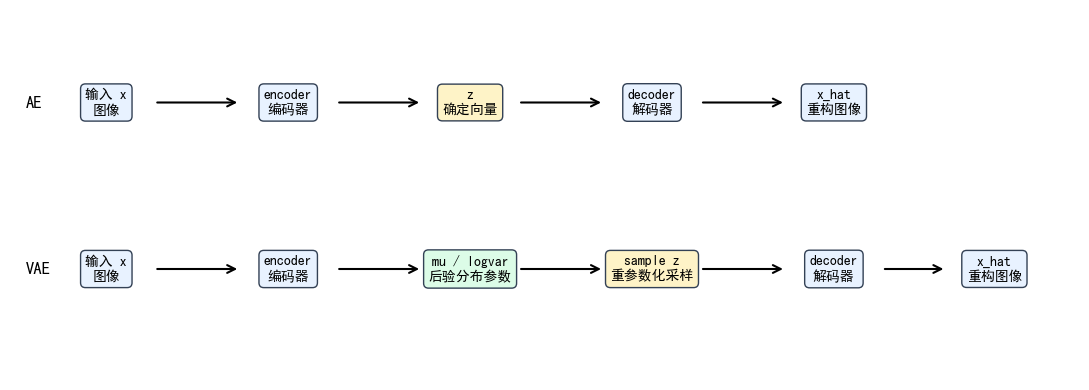

In [2]:
def draw_box(ax, x, y, text, facecolor='#E8F2FF'):
    ax.text(
        x,
        y,
        text,
        ha='center',
        va='center',
        fontsize=10,
        bbox={'boxstyle': 'round,pad=0.35', 'facecolor': facecolor, 'edgecolor': '#334155'},
    )

def draw_arrow(ax, start, end):
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=14, linewidth=1.5))

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# 上半部分：普通 AE 的路径，只有一个确定的中间向量 z。
draw_box(ax, 0.9, 3.0, '输入 x\n图像')
draw_box(ax, 2.6, 3.0, 'encoder\n编码器')
draw_box(ax, 4.3, 3.0, 'z\n确定向量', '#FEF3C7')
draw_box(ax, 6.0, 3.0, 'decoder\n解码器')
draw_box(ax, 7.7, 3.0, 'x_hat\n重构图像')

# 下半部分：VAE 的路径，先预测分布参数，再采样出 z。
draw_box(ax, 0.9, 1.2, '输入 x\n图像')
draw_box(ax, 2.6, 1.2, 'encoder\n编码器')
draw_box(ax, 4.3, 1.2, 'mu / logvar\n后验分布参数', '#DCFCE7')
draw_box(ax, 6.0, 1.2, 'sample z\n重参数化采样', '#FEF3C7')
draw_box(ax, 7.7, 1.2, 'decoder\n解码器')
draw_box(ax, 9.2, 1.2, 'x_hat\n重构图像')

for y, xs in [(3.0, [0.9, 2.6, 4.3, 6.0, 7.7]), (1.2, [0.9, 2.6, 4.3, 6.0, 7.7, 9.2])]:
    for left, right in zip(xs, xs[1:]):
        draw_arrow(ax, (left + 0.45, y), (right - 0.45, y))

ax.text(0.15, 3.0, 'AE', fontsize=12, fontweight='bold', va='center')
ax.text(0.15, 1.2, 'VAE', fontsize=12, fontweight='bold', va='center')
plt.tight_layout()
plt.show()


## 概率建模直觉：`z`、`p(z)`、`q(z|x)`、`p(x|z)` 分别是什么

VAE 把生成过程写成：先从 `p(z)` 采潜变量，再由 `p(x|z)` 生成图像。训练时只有图像 `x`，真实后验 `p(z|x)` 很难直接计算，所以用 encoder（编码器）表示的 `q(z|x)` 去近似它。


| 符号 | 直觉 | 在本项目中的对应物 |
| --- | --- | --- |
| `z` | 描述图像隐藏因素的 latent vector（潜变量向量） | `output['z']` |
| `p(z)` | 生成时使用的 prior（先验分布），通常是 `N(0, I)` | `torch.randn(...)` |
| `q(z\|x)` | encoder（编码器）给定图像后预测的近似 posterior（后验分布） | `mu` 和 `logvar` 定义的高斯分布 |
| `p(x\|z)` | decoder（解码器）给定 `z` 后对像素的分布 | decoder 输出的 Bernoulli logits（伯努利分布原始输出） |


这里的 `q` 和 `p` 不是四个独立网络。Encoder（编码器）负责给出 `q(z|x)` 的参数，decoder（解码器）负责给出 `p(x|z)` 的参数，而 `p(z)=N(0,I)` 是我们预先选择的简单分布。


## 如何从 FakeData 切到 MNIST，再切到 Fashion-MNIST

默认的 `dataset: 'fake'` 使用 FakeData（随机假数据）。`fake`（FakeData）只用于离线 smoke/学习；这里的 smoke test（烟雾测试）意思是“只验证流程能跑通”，可以验证 shape（张量形状）、loss（损失）和训练路径，但随机图案不会产生有语义的生成效果。

`mnist`（MNIST）用于真实数据上的代码调试，容易观察数字轮廓。`fashion_mnist`（Fashion-MNIST）是作业要求的主实验/正式实验数据集，最终的 `beta=1` 与 `beta=0` 比较必须在它上面完成。真实数据需要事先下载或把 `download` 显式改为 `True`；本 notebook 默认不触发下载。


### 先使用离线小配置

限制训练和测试样本数，只跑少量 batch。固定随机种子并使用 CPU，使教学结果更容易复现。图像经 `ToTensor()` 后位于 `[0, 1]`。


In [3]:
# 这个小配置只用于离线学习和快速验证，不代表正式实验设置
config = validate_config({
    'run_name': 'notebook_smoke',
    'dataset': 'fake',
    'data_dir': 'data',
    'output_dir': 'outputs/notebook_smoke',
    'batch_size': 32,
    'epochs': 1,
    'learning_rate': 1e-3,
    'seed': 42,
    'device': 'cpu',
    'beta': 1.0,
    'latent_dim': 8,
    'hidden_dims': [128, 64],
    'train_limit': 128,
    'test_limit': 64,
    'num_workers': 0,
    'download': False,
    'sample_count': 16,
})
set_seed(config['seed'])
device = select_device(config['device'])
train_loader, test_loader = get_dataloaders(config)
device, len(train_loader), len(test_loader)


(device(type='cpu'), 4, 2)

### 检查一个 batch 的 shape 和数值范围

模型期望输入 shape（张量形状）为 `[batch, channel, height, width]`，也就是 `[一小批样本数, 通道数, 高, 宽]`。在计算 BCE 前，还应确认 target（目标图像）像素确实位于 `[0, 1]`。


In [4]:
# 取出一个 batch（一小批样本），先检查数据长什么样
images, labels = next(iter(train_loader))
batch_summary = {
    'images_shape': tuple(images.shape),
    'labels_shape': tuple(labels.shape),
    'pixel_min': float(images.min()),
    'pixel_max': float(images.max()),
    'dtype': str(images.dtype),
}
batch_summary


{'images_shape': (32, 1, 28, 28),
 'labels_shape': (32,),
 'pixel_min': 0.0,
 'pixel_max': 1.0,
 'dtype': 'torch.float32'}

### 先看输入图像

FakeData 的图像是用于打通流程的随机模式，不要把它误读成模型失败。切换到 MNIST 或 Fashion-MNIST 后，才应期待数字或服饰轮廓。


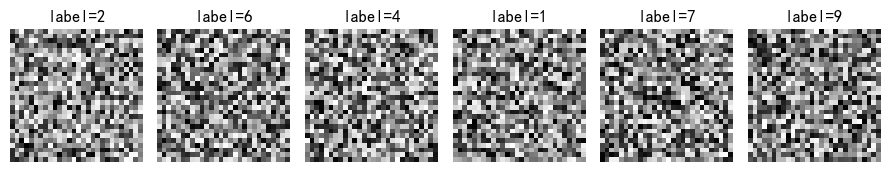

In [5]:
fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for index, axis in enumerate(axes):
    axis.imshow(images[index, 0], cmap='gray', vmin=0, vmax=1)
    axis.set_title(f'label={int(labels[index])}')
    axis.axis('off')
plt.tight_layout()
plt.show()


## Encoder 为什么输出 `mu` 和 `logvar`

Encoder（编码器）是把图像变成潜变量分布参数的网络。VAE 不把一张图编码成单点，而是编码成对角高斯分布 `q(z|x)=N(mu, diag(sigma^2))`。`mu` 表示分布中心，方差表示对每个 latent dimension（潜变量维度）的不确定性。


网络输出 `logvar = log(sigma^2)` 而不是直接输出 `sigma`。这样输出可以是任意实数，不需要额外保证方差为正；需要标准差时使用 `std = exp(0.5 * logvar)`，结果自然大于零。


In [6]:
model = MLPVAE(
    input_shape=(1, 28, 28),
    hidden_dims=config['hidden_dims'],
    latent_dim=config['latent_dim'],
).to(device)
images = images.to(device)
# 编码器输出后验分布 q(z|x) 的两个参数：mu 和 logvar
mu, logvar = model.encode(images)
mu.shape, logvar.shape


(torch.Size([32, 8]), torch.Size([32, 8]))

### 查看 `mu`、`logvar`、`std` 和一次采样的 `z`

先只看第一张图和前四个 latent dimensions（潜变量维度）。初始网络尚未训练，数值本身没有语义；重点是四者的计算关系和相同 shape（张量形状）。


In [7]:
std = torch.exp(0.5 * logvar)
latent_generator = torch.Generator(device='cpu').manual_seed(config['seed'])
# 重参数化采样：把随机性放在 epsilon 里，z 仍然能对 mu/std 求梯度
z = model.reparameterize(mu, logvar, sample=True, generator=latent_generator)
{
    'mu': mu[0, :4].detach().cpu(),
    'logvar': logvar[0, :4].detach().cpu(),
    'std': std[0, :4].detach().cpu(),
    'sampled_z': z[0, :4].detach().cpu(),
}


{'mu': tensor([-0.0658, -0.1169, -0.0879,  0.0539]),
 'logvar': tensor([ 0.0852,  0.0344, -0.0703, -0.0969]),
 'std': tensor([1.0435, 1.0174, 0.9655, 0.9527]),
 'sampled_z': tensor([ 1.9450,  1.3962,  0.7817, -1.9520])}

## 重参数化技巧为什么能让采样参与反向传播

如果把 `z ~ N(mu, sigma^2)` 当作一个黑盒随机操作，梯度无法说明随机样本怎样随 `mu`、`sigma` 改变。重参数化把它改写为 `epsilon ~ N(0,I)` 与 `z = mu + std * epsilon`。


随机性被移到与参数无关的 `epsilon`；给定一次 `epsilon` 后，`z` 是 `mu` 和 `std` 的普通可微函数。因此 reconstruction loss 的梯度可以沿 `decoder -> z -> mu/std -> encoder` 回传。采样仍然存在，只是采样源不再包含待学习参数。


### 重参数化技巧的计算路径图

这张图把 `z = mu + std * epsilon` 拆开看：`epsilon` 负责提供随机性，`mu` 和 `std` 仍然通过普通加法、乘法影响 `z`，所以梯度可以从重构损失一路回到编码器。


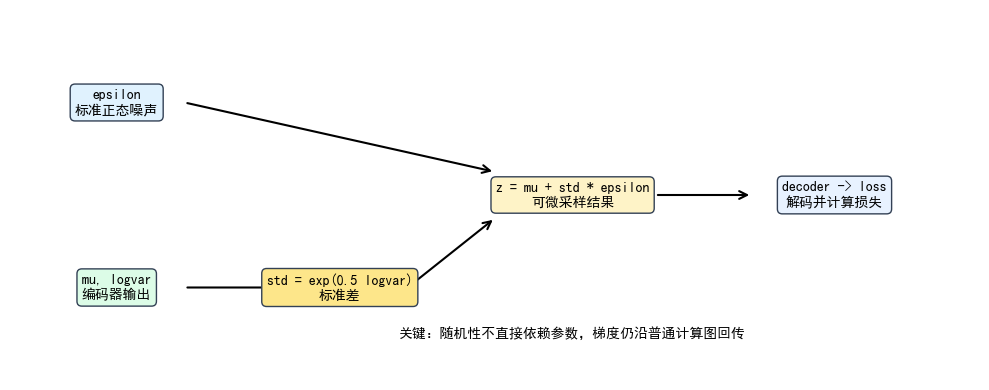

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# 重参数化图：epsilon 是随机源，mu/std 是 encoder 输出的可学习路径。
draw_box(ax, 1.1, 3.0, 'epsilon\n标准正态噪声', '#E0F2FE')
draw_box(ax, 1.1, 1.0, 'mu, logvar\n编码器输出', '#DCFCE7')
draw_box(ax, 3.4, 1.0, 'std = exp(0.5 logvar)\n标准差', '#FDE68A')
draw_box(ax, 5.8, 2.0, 'z = mu + std * epsilon\n可微采样结果', '#FEF3C7')
draw_box(ax, 8.5, 2.0, 'decoder -> loss\n解码并计算损失', '#E8F2FF')

draw_arrow(ax, (1.8, 3.0), (5.0, 2.25))
draw_arrow(ax, (1.8, 1.0), (2.75, 1.0))
draw_arrow(ax, (4.1, 1.0), (5.0, 1.75))
draw_arrow(ax, (6.65, 2.0), (7.65, 2.0))
ax.text(5.8, 0.45, '关键：随机性不直接依赖参数，梯度仍沿普通计算图回传', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


In [9]:
manual_generator = torch.Generator(device='cpu').manual_seed(7)
epsilon = torch.randn(std.shape, generator=manual_generator, device='cpu').to(device)
manual_z = mu + std * epsilon
manual_z.requires_grad, manual_z.grad_fn


(True, <AddBackward0 at 0x750ec1f42d40>)

## ELBO 直觉：重构项和 KL 项各自在约束什么

ELBO（evidence lower bound，证据下界）是 VAE 推导里的核心目标。实际训练常最小化它的相反数，也就是负 ELBO。

当 `beta=1` 时，`reconstruction + KL` 是负 ELBO：这里的 reconstruction（重构项）是负对数似然（本项目用 BCE 计算），所以最小化它等价于最大化 ELBO。两个项会拉扯：重构项希望每个 `z` 保留足够多的输入细节；KL 项希望每个 `q(z|x)` 不要偏离统一的先验 `N(0,I)` 太远。

当 `beta != 1`（包括本作业的 `beta=0`）时，`reconstruction + beta * KL` 是 beta-VAE 加权目标 / 消融目标，不是标准 ELBO。它仍然是有用的训练目标，但其目的变为刻意改变重构与先验对齐之间的权衡。


- **重构项**约束 decoder 能否由当前 `z` 解释输入，回答“信息够不够”。
- **KL 项**约束 encoder 的分布能否与生成时的先验对齐，回答“潜空间能不能直接采”。
- **`beta`**控制两者权衡；本作业用 `beta=1` 与 `beta=0` 做最直接的消融比较。


In [10]:
output = model(images, sample=True)
losses = vae_loss(
    output['recon_logits'], images, output['mu'], output['logvar'], beta=config['beta']
)
{name: float(value.detach().cpu()) for name, value in losses.items()}


{'total': 544.4310913085938,
 'reconstruction': 544.3651123046875,
 'kl': 0.06595615297555923}

## KL 公式和代码如何对应

对角高斯 `q(z|x)=N(mu, diag(sigma^2))` 与标准正态先验的 KL 为：

`KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))`。

代码先对 latent dimensions（潜变量维度）求和得到每个样本的 KL，再对 batch（一小批样本）求平均。


公式中的 `1` 是常数；`logvar` 对应 `log(sigma^2)`；`mu.pow(2)` 惩罚均值偏离 0；`logvar.exp()` 还原方差并惩罚它偏离 1。若 `mu=0` 且 `logvar=0`，则方差为 1，每一维括号内恰好为 0。


In [11]:
standard_mu = torch.zeros(1, 4)
standard_logvar = torch.zeros(1, 4)
shifted_mu = torch.ones(1, 4)
standard_kl = kl_divergence_standard_normal(standard_mu, standard_logvar)
shifted_kl = kl_divergence_standard_normal(shifted_mu, standard_logvar)
{'standard_normal_KL': float(standard_kl), 'shifted_posterior_KL': float(shifted_kl)}


{'standard_normal_KL': 0.0, 'shifted_posterior_KL': 2.0}

标准正态 posterior 的 KL 应为 0；仅把四维均值都移到 1 后，KL 应变为正数。这个小例子把“KL 衡量与先验的距离”变成可检查的数值。


## BCE reconstruction loss、logits、sigmoid 的关系

Decoder（解码器）输出的是 raw logits（原始 logits），不是已经位于 `[0,1]` 的像素。logits（未经过 sigmoid 的原始输出）经过 `sigmoid(logits)` 后，才会变成 Bernoulli（伯努利）概率或可显示的灰度值。训练使用 `binary_cross_entropy_with_logits`，它在一个数值稳定的操作里组合 sigmoid 和 BCE。


因此有两个容易混淆但必须分开的规则：把 `recon_logits` 直接交给 loss；显示或保存图像前再调用 sigmoid。若训练前手动 sigmoid，再使用 `BCEWithLogits`，就相当于重复做了一次 sigmoid。


In [12]:
example_logits = torch.tensor([-4.0, 0.0, 4.0])
example_probabilities = torch.sigmoid(example_logits)
torch.stack([example_logits, example_probabilities], dim=1)


tensor([[-4.0000,  0.0180],
        [ 0.0000,  0.5000],
        [ 4.0000,  0.9820]])

## 训练循环逐步拆解：forward、loss、backward、optimizer

一个 batch（一小批样本）的学习过程固定由四步组成：forward（前向计算）、loss（损失计算）、backward（反向传播）和 optimizer（优化器更新）。理解顺序比记住 API 更重要，因为漏掉清梯度、反向传播或参数更新都会让训练行为改变。


### 1. forward

`output = model(batch_images)` 依次执行 encoder（编码器）、重参数化和 decoder（解码器），返回 `recon_logits`、`mu`、`logvar`、`z`。调用 `model.train()` 后，默认会采样 latent（潜变量）。


### 2. loss

`vae_loss(...)` 用 target（目标）图像和 logits（未经过 sigmoid 的原始输出）算 reconstruction（重构损失），再用 `mu/logvar` 算 KL，最后得到 `total = reconstruction + beta * KL`。只有 `total` 用于反向传播，另外两项用于诊断。


### 3. backward

先用 `optimizer.zero_grad(set_to_none=True)` 清除上一 batch（一小批样本）的梯度，再调用 `losses['total'].backward()`。Autograd（自动求导）会沿 decoder（解码器）、重参数化表达式和 encoder（编码器）计算梯度。


### 4. optimizer

`optimizer.step()` 根据刚算出的梯度更新参数。它必须发生在 backward（反向传播）之后；参数更新完成后，才进入下一个 batch（一小批样本）。


### 在 FakeData 上运行一个 tiny training loop

下面只训练三个 batch，目的是验证完整学习路径，而不是获得有意义的图像质量。记录 total、reconstruction 和 KL，方便确认三项都是有限数值。


In [13]:
set_seed(config['seed'])
optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
tiny_history = []
model.train()
for step, (batch_images, _batch_labels) in enumerate(train_loader, start=1):
    batch_images = batch_images.to(device)
    optimizer.zero_grad(set_to_none=True)
    # 前向计算：图像 -> mu/logvar -> z -> recon_logits
    output = model(batch_images)
    losses = vae_loss(
        output['recon_logits'], batch_images, output['mu'], output['logvar'], beta=config['beta']
    )
    # 反向传播：根据 total loss 计算每个参数的梯度
    losses['total'].backward()
    # 优化器更新：根据刚才算出的梯度修改模型参数
    optimizer.step()
    tiny_history.append({name: float(value.detach().cpu()) for name, value in losses.items()})
    if step == 3:
        break
tiny_history


[{'total': 544.2435302734375,
  'reconstruction': 544.1775512695312,
  'kl': 0.06595615297555923},
 {'total': 544.1610107421875,
  'reconstruction': 544.1195678710938,
  'kl': 0.04141495004296303},
 {'total': 544.4354248046875,
  'reconstruction': 544.405029296875,
  'kl': 0.030390698462724686}]

训练时优先检查：loss 是否有限、是否整体下降、KL 是否长期接近 0、reconstruction 与 KL 的量级是否严重失衡。三个 FakeData batch 只能做 smoke test，不能用于判断收敛。


## 重构图怎么看

重构图比较“给模型一张图后，它保留了多少输入信息”。本项目保存的网格上排是原图，下排是对应重构；位置一一对应。先看大轮廓，再看类别特征和细节，不要只凭是否清晰下结论。


重构模糊可能来自训练不足、latent dimension（潜变量维度）太小、KL 约束太强，或 BCE 倾向输出平均化像素。重构好只说明 encoder-decoder（编码器到解码器）路径有效，不自动证明先验采样有效。


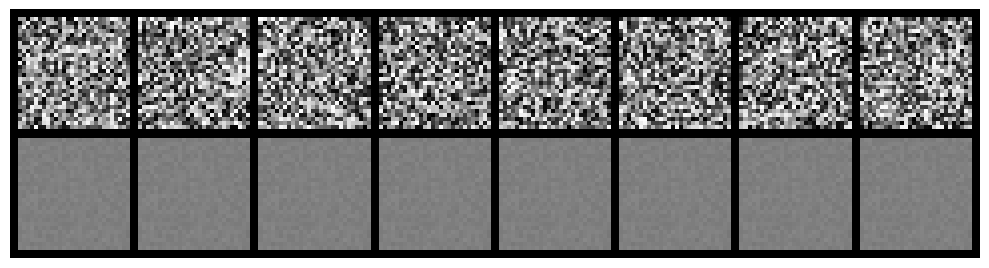

In [14]:
figures_dir = Path(config['output_dir']) / 'figures'
reconstruction_path = figures_dir / 'notebook_reconstructions.png'
save_reconstruction_grid(model, test_loader, device, reconstruction_path, max_images=8)
plt.figure(figsize=(10, 3))
plt.imshow(plt.imread(reconstruction_path))
plt.axis('off')
plt.tight_layout()
plt.show()


## 先验采样图怎么看

先验采样不提供输入图像，而是直接取 `z ~ N(0,I)` 再 decode（解码）。它检验的是训练得到的 latent space（潜空间）是否与生成时使用的先验对齐，所以比重构更直接地反映 VAE 的生成能力。


观察时看三点：单张样本是否像数据分布；不同格子是否有多样性；是否存在大量噪声或几乎相同的输出。FakeData 没有稳定语义，正式判断必须使用训练充分的 Fashion-MNIST 模型。


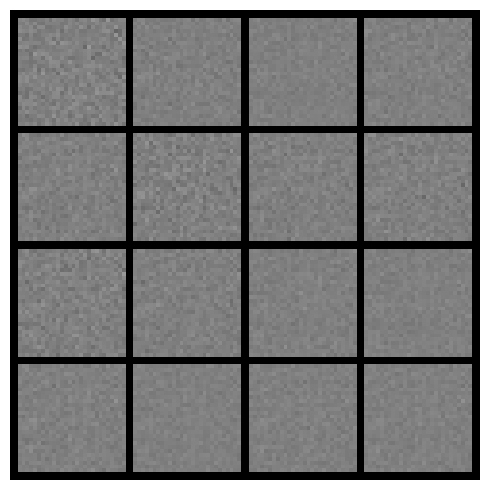

In [15]:
prior_path = figures_dir / 'notebook_prior_samples.png'
prior_generator = torch.Generator(device='cpu').manual_seed(config['seed'])
prior_latents = torch.randn(16, model.latent_dim, generator=prior_generator)
save_prior_samples(model, device, prior_path, latents=prior_latents)
plt.figure(figsize=(5, 5))
plt.imshow(plt.imread(prior_path))
plt.axis('off')
plt.tight_layout()
plt.show()


## `beta=1` vs `beta=0` 运行前应该预期什么

`beta=1` 使用标准 VAE 的负 ELBO 目标；`beta=0` 完全移除 KL 对 total loss（总损失）的影响，因此是消融目标而不是标准 ELBO。公平比较时只改变 beta，保持数据、网络、seed（随机种子）、epoch（一轮训练）、batch size（一小批样本大小）和学习率一致。


| 观察项 | `beta=1` 的预期 | `beta=0` 的预期 |
| --- | --- | --- |
| reconstruction（重构误差） | 可能略差 | 可能更好 |
| KL | 被纳入优化，通常受控 | 仍可计算，但没有梯度权重，可能漂移 |
| prior samples（先验采样图） | 更可能形成可识别且连续的样本 | 可能差，即使重构很好 |
| latent space（潜空间） | 更接近 `N(0,I)` | 只服务于重构，没有先验对齐保证 |

这些是运行前的假设，不是必须出现的结论；最终要用 loss 曲线、重构网格和先验采样网格共同验证。


### beta 对潜空间和采样的影响示意图

下面的二维散点图只是概念图，不是训练结果。左图表示 `beta=1` 时，后验分布更倾向于贴近标准正态先验；右图表示 `beta=0` 时，潜空间可能只围绕重构任务形成分散区域，随机从标准正态采样时更容易落在模型不熟悉的位置。


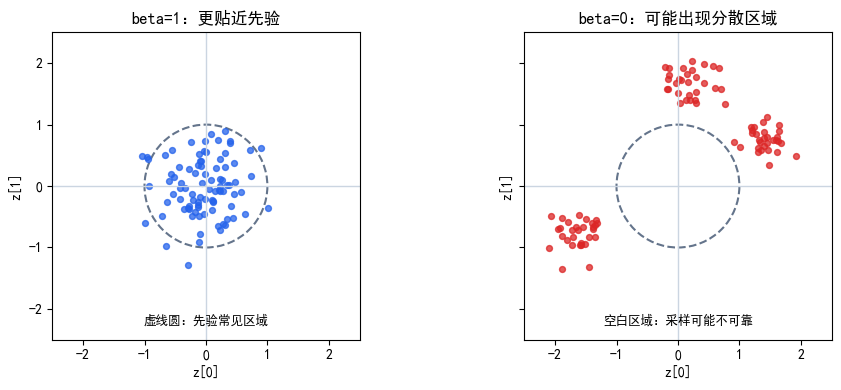

In [16]:
generator = torch.Generator(device='cpu').manual_seed(123)
beta1_points = torch.randn(90, 2, generator=generator) * 0.45
centers = torch.tensor([[-1.6, -0.7], [1.4, 0.8], [0.2, 1.8]])
beta0_parts = []
for center in centers:
    beta0_parts.append(center + torch.randn(30, 2, generator=generator) * 0.22)
beta0_points = torch.cat(beta0_parts, dim=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for axis, title in zip(axes, ['beta=1：更贴近先验', 'beta=0：可能出现分散区域']):
    axis.add_patch(Circle((0, 0), 1.0, fill=False, linestyle='--', linewidth=1.5, edgecolor='#64748B'))
    axis.axhline(0, color='#CBD5E1', linewidth=1)
    axis.axvline(0, color='#CBD5E1', linewidth=1)
    axis.set_xlim(-2.5, 2.5)
    axis.set_ylim(-2.5, 2.5)
    axis.set_aspect('equal')
    axis.set_title(title)
    axis.set_xlabel('z[0]')
    axis.set_ylabel('z[1]')

# 左图：点集中在标准正态先验的常见区域，随机采样更容易落在模型熟悉的位置。
axes[0].scatter(beta1_points[:, 0], beta1_points[:, 1], s=18, alpha=0.75, color='#2563EB')
axes[0].text(0, -2.25, '虚线圆：先验常见区域', ha='center', fontsize=9)

# 右图：点形成几个孤立团块，中间空洞可能导致先验采样质量下降。
axes[1].scatter(beta0_points[:, 0], beta0_points[:, 1], s=18, alpha=0.75, color='#DC2626')
axes[1].text(0, -2.25, '空白区域：采样可能不可靠', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### 数据集切换配置

下面只展示配置差异，不创建真实数据 loader，因此不会下载。已有本地数据时可保持 `download=False`；需要首次下载时，由你主动改为 `True`。


In [17]:
dataset_modes = {
    'offline_learning': {'dataset': 'fake', 'download': False},
    'real_data_debugging': {'dataset': 'mnist', 'download': False},
    'formal_assignment': {'dataset': 'fashion_mnist', 'download': False},
}
dataset_modes


{'offline_learning': {'dataset': 'fake', 'download': False},
 'real_data_debugging': {'dataset': 'mnist', 'download': False},
 'formal_assignment': {'dataset': 'fashion_mnist', 'download': False}}

## 常见问题：posterior collapse、KL 太小/太大、采样差但重构好

**Posterior collapse（后验塌陷）** 指 encoder（编码器）的 `q(z|x)` 几乎退化为与输入无关的先验，decoder（解码器）很少使用 `z`。典型信号是 KL 长期接近 0、不同输入的 `mu` 很相似，以及改变 `z` 对输出影响很小。


- **KL 太小**：先确认 decoder（解码器）是否忽略 `z`、beta 是否过强、训练是否充分。KL 小不总是好事。
- **KL 太大**：posterior（后验分布）与先验偏离明显；检查 loss reduction（损失归约方式）、输入范围、学习率和 beta。
- **采样差但重构好**：常见于 `beta=0` 或先验对齐不足。重构使用 `q(z|x)` 附近的点，而生成使用 `p(z)` 的点，两者可能不在同一区域。
- **所有样本很像**：检查训练不足、模型容量、数据问题，也要结合 KL 判断是否 collapse。


## 读完后你应该能回答的问题

1. 普通 AE 的 latent space（潜空间）为什么不能保证随机采样有效？
2. `p(z)`、`q(z|x)` 和 `p(x|z)` 分别由什么定义？
3. 为什么 encoder（编码器）输出 `logvar`，而不是直接输出标准差？
4. `z = mu + std * epsilon` 为什么保留了到 encoder（编码器）的梯度路径？
5. KL 为 0 在数学上意味着什么？训练中 KL 长期接近 0 又可能意味着什么？
6. 为什么 loss（损失函数）接收 logits（未经过 sigmoid 的原始输出），而可视化必须使用 sigmoid 后的值？
7. 一个训练 batch（一小批样本）中 forward（前向计算）、loss（损失计算）、backward（反向传播）、optimizer（优化器）的顺序是什么？
8. 重构好但先验采样差，说明潜空间可能有什么问题？
9. 比较 `beta=1` 与 `beta=0` 时，哪些设置必须保持不变？
10. FakeData、MNIST、Fashion-MNIST 在本项目中分别承担什么角色？


### 答辩前最后自检

不要只背公式。尝试用一张图的路径讲完整故事：`x -> mu/logvar -> z -> logits -> reconstruction loss`，也就是“输入图像 -> 后验分布参数 -> 潜变量 -> 原始像素输出 -> 重构损失”。再解释 KL 怎样让这条重构路径与 `z ~ N(0,I)` 的生成路径连接起来。最后用 `beta=0` 的反例说明为什么“重构好”不等于“会生成”。
